In [8]:
from hetero_isas.monodromy_lp import (
    MonodromyLPDecomposer,
)
from hetero_isas.monodromy_lp.isa import ISAHandler
from qiskit.circuit.library import CXGate, SwapGate, iSwapGate
from qiskit.quantum_info import Operator, average_gate_fidelity, random_unitary
from qutip import Qobj
from weylchamber import c1c2c3

%matplotlib inline

In [2]:
# first must define the ISA for the decomposer
isa_handler = ISAHandler(
    [
        CXGate(),
        CXGate().power(1 / 2),
        iSwapGate().power(1 / 2),
        iSwapGate().power(1 / 3),
    ],
    [1.0, 1 / 2, 1 / 2, 1 / 3],
    ["cx,", "sq[2]cx", "sq[2]iswap", "sq[3]iswap"],
)

# instantiate a decomposer
scipy_decomposer = MonodromyLPDecomposer(isa_handler)
# cplex_decomposer = MonodromyLPDecomposer(isa_handler, use_ordered_sequences=False)
decomposer = scipy_decomposer

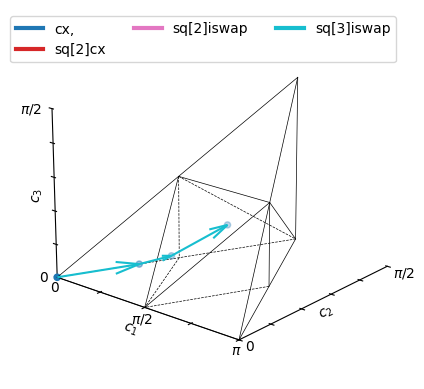

In [9]:
# the first step of the decomposer, _best_decomposition()
# is only responsible for finding an optimal sequence of 2Q gates
# the second step, decomposer.numeric_decomposer.run()
# fits the single qubit gate parameters for each segment of the trajectory

target_gate = random_unitary(4).to_matrix()
mono_result = decomposer._best_decomposition(target_gate)
mono_result.render_path();

(np.float64(0.46901273), np.float64(0.33835902), np.float64(0.26582976))


Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-0.05017437+0.06774609j -0.28787461-0.42133683j -0.61101608-0.06079462j
   0.54964523-0.23097611j]
 [ 0.09717   +0.63544289j -0.50370657-0.34219147j  0.16852573-0.16855637j
  -0.33749767+0.21269267j]
 [-0.1778776 +0.24983126j  0.2328073 +0.12822814j -0.603739  +0.39943178j
  -0.24266655+0.50236304j]
 [-0.40961567+0.56375724j  0.04166274+0.54443613j  0.12149509-0.16535903j
   0.40199118-0.11200321j]]

1.000000000000001


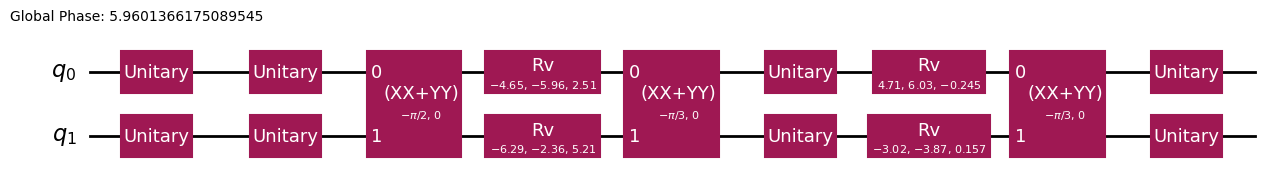

In [18]:
target = random_unitary(4).to_matrix()  # SwapGate()
result = decomposer(target)
result_u = Operator(result).data
print(c1c2c3(result_u))
display(Qobj(result_u))  # inspect for correctness
print(average_gate_fidelity(Operator(result_u), Operator(target)))
result.draw("mpl");

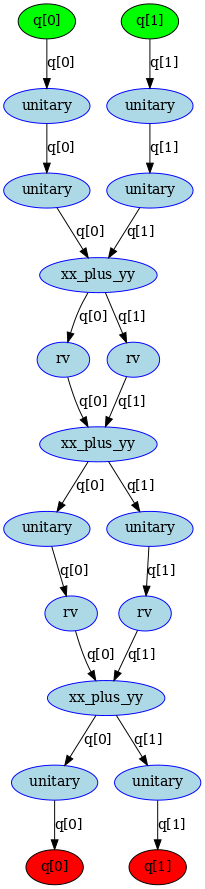

In [7]:
decomp_dag = decomposer(SwapGate(), use_dag=True)
decomp_dag.draw()